<a href="https://colab.research.google.com/github/jdansb/Econophysics/blob/main/files/fkkerplanck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np

# sistema
def ode(w, y):

    P = y[0]
    A = y[1]
    B = y[2]

    denom = 0.5*A*(w**2) + B

    dP = ((1 - w - w*A)*P)/denom
    dA = -P
    dB = 0.5*P*(w**2)

    return np.vstack((dP,dA,dB))

# Contorno
wmax = 200

def bc(ya,yb):

    return np.array([
        ya[1]-1,
        ya[2],
        yb[1]
    ])


  #chute inicial

w = np.linspace(1e-3, wmax, 400)
P0 = np.exp(-w)
A0 = np.exp(-w)
B0 = 0.25*np.ones_like(w)
guess = np.vstack((P0,A0,B0))

In [23]:
from scipy.integrate import solve_bvp

sol = solve_bvp(
        ode,
        bc,
        w,
        guess,
        max_nodes=20000
)

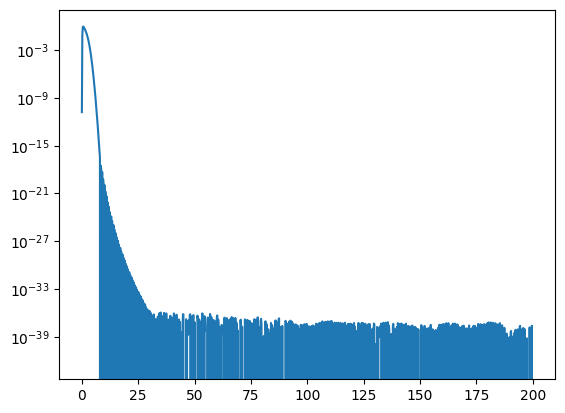

In [24]:
import matplotlib.pyplot as plt

ww = np.linspace(1e-3, wmax, 1000)

P = sol.sol(ww)[0]

plt.semilogy(ww,P)
#plt.loglog(ww,P)
plt.show()

Procurando o valor correto de P(w_start)...
Convergência alcançada! O valor de P(0.1) é: 5.73e-05


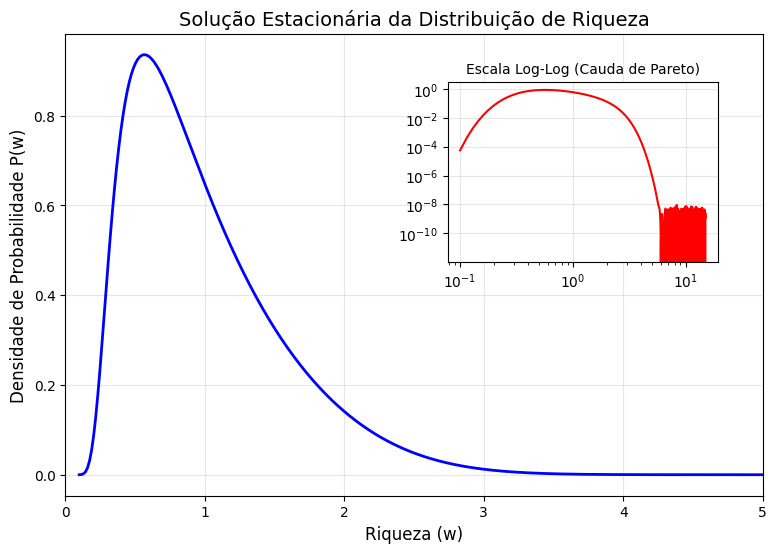

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

# ==========================================
# 1. Parâmetros de Integração
# ==========================================
w_start = 0.1   # Ponto de partida longe do zero absoluto para evitar underflow (e^{-2/w})
w_end = 15.0    # Valor alto que representa o "infinito" para a riqueza

# ==========================================
# 2. Definição do Sistema de EDOs
# ==========================================
def model_odes(w, y):
    P, A, B = y

    # Prevenção numérica: garante que o denominador nunca zere por flutuação de máquina
    denominador = (w**2 / 2.0) * A + B
    if denominador <= 0:
        denominador = 1e-15

    # As três equações diferenciais deduzidas analiticamente
    dP_dw = ((1.0 - w - w * A) / denominador) * P
    dA_dw = -P
    dB_dw = (w**2 / 2.0) * P

    return [dP_dw, dA_dw, dB_dw]

# ==========================================
# 3. O Método do Tiro (Shooting Method)
# ==========================================
def shoot(p0):
    """
    Dado um "chute" inicial p0 para P(w_start), resolve o sistema de EDOs.
    Retorna o valor de A(w_end). O objetivo é que A(w_end) seja igual a 0.
    """
    # Condições iniciais em w_start:
    # A integral A(w_start) é aproximadamente 1, pois quase toda probabilidade está à frente
    # B(w_start) é aproximadamente 0
    y0 = [p0, 1.0, 0.0]

    sol = solve_ivp(
        model_odes,
        [w_start, w_end],
        y0,
        method='RK45',
        rtol=1e-8,
        atol=1e-8
    )

    # O retorno é a diferença entre o A final calculado e o A final desejado (0)
    A_final = sol.y[1, -1]
    return A_final

# ==========================================
# 4. Solução e Otimização
# ==========================================
print("Procurando o valor correto de P(w_start)...")

try:
    # Busca da raiz usando o método de Brent.
    # Os limites (bracket) representam palpites mínimos e máximos para P(w_start).
    # Em problemas físicos complexos, esses limites podem precisar de ajuste manual.
    res = root_scalar(shoot, bracket=[1e-10, 0.5], method='brentq')
    p0_opt = res.root
    print(f"Convergência alcançada! O valor de P({w_start}) é: {p0_opt:.2e}")

    # Resolve novamente o sistema usando o p0 ótimo para armazenar os dados e plotar
    sol_final = solve_ivp(
        model_odes,
        [w_start, w_end],
        [p0_opt, 1.0, 0.0],
        t_eval=np.linspace(w_start, w_end, 1000), # Mais pontos para um plot suave
        method='RK45',
        rtol=1e-8,
        atol=1e-8
    )

    w_vals = sol_final.t
    P_vals = sol_final.y[0]

    # ==========================================
    # 5. Visualização dos Gráficos
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(9, 6))

    # Gráfico Linear (Linear Scale)
    ax1.plot(w_vals, P_vals, color='blue', linewidth=2)
    ax1.set_xlabel('Riqueza (w)', fontsize=12)
    ax1.set_ylabel('Densidade de Probabilidade P(w)', fontsize=12)
    ax1.set_title('Solução Estacionária da Distribuição de Riqueza', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 5) # Foco na região principal

    # Gráfico Log-Log Embutido (Inset) para demonstrar a Cauda de Pareto
    ax2 = fig.add_axes([0.55, 0.5, 0.3, 0.3]) # Coordenadas: [esquerda, baixo, largura, altura]
    ax2.loglog(w_vals, P_vals, color='red', linewidth=1.5)
    ax2.set_title('Escala Log-Log (Cauda de Pareto)', fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.show()

except ValueError as e:
    print("O algoritmo não encontrou a raiz no intervalo fornecido.")
    print("Detalhe do Erro:", e)
    print("Dica: Se houver falha, tente alterar o 'bracket' no root_scalar para abranger a raiz.")

Procurando o valor correto de P(w_start) para tau=1.0 e beta=1.0...
Convergência alcançada! O valor de P(0.1) é: 5.73e-05


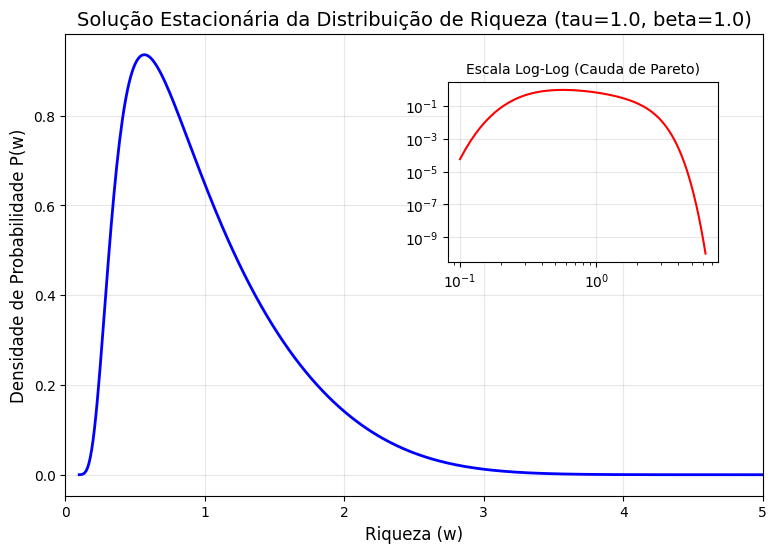

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

# ==========================================
# 1. Parâmetros do Modelo e Integração
# ==========================================
tau = 1.0       # Taxa de redistribuição (deriva)
beta = 1.0      # Intensidade das flutuações comerciais (difusão)

# A razão lambda = tau / beta^2 controla o balanço da equação e a forma da cauda
lam = tau / (beta**2)

w_start = 0.1   # Ponto de partida longe do zero absoluto para evitar underflow
w_end = 20.0    # Valor alto para a riqueza (expandido para visualizar melhor a cauda)

# ==========================================
# 2. Definição do Sistema de EDOs
# ==========================================
def model_odes(w, y):
    P, A, B = y

    # Prevenção numérica: garante que o denominador nunca zere
    denominador = (w**2 / 2.0) * A + B
    if denominador <= 0:
        denominador = 1e-15

    # Sistema de EDOs com o parâmetro lambda embutido no numerador
    dP_dw = ((lam * (1.0 - w) - w * A) / denominador) * P
    dA_dw = -P
    dB_dw = (w**2 / 2.0) * P

    return [dP_dw, dA_dw, dB_dw]

# ==========================================
# 3. O Método do Tiro (Shooting Method)
# ==========================================
def shoot(p0):
    y0 = [p0, 1.0, 0.0]

    sol = solve_ivp(
        model_odes,
        [w_start, w_end],
        y0,
        method='RK45',
        rtol=1e-12,  # Precisão numérica aumentada
        atol=1e-14   # Precisão numérica aumentada
    )

    # Retorna o valor final de A, que fisicamente deve ser 0
    return sol.y[1, -1]

# ==========================================
# 4. Solução e Otimização
# ==========================================
print(f"Procurando o valor correto de P(w_start) para tau={tau} e beta={beta}...")

try:
    # Busca da raiz. O limite superior do bracket foi levemente ampliado para
    # acomodar as variações introduzidas pelos novos parâmetros.
    res = root_scalar(shoot, bracket=[1e-10, 2.0], method='brentq')
    p0_opt = res.root
    print(f"Convergência alcançada! O valor de P({w_start}) é: {p0_opt:.2e}")

    # Resolução final com mais pontos para plotagem suave
    sol_final = solve_ivp(
        model_odes,
        [w_start, w_end],
        [p0_opt, 1.0, 0.0],
        t_eval=np.linspace(w_start, w_end, 2000),
        method='RK45',
        rtol=1e-12,
        atol=1e-14
    )

    w_vals = sol_final.t
    P_vals = sol_final.y[0]

    # ==========================================
    # 5. Visualização dos Gráficos
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(9, 6))

    # Gráfico Linear (Linear Scale)
    ax1.plot(w_vals, P_vals, color='blue', linewidth=2)
    ax1.set_xlabel('Riqueza (w)', fontsize=12)
    ax1.set_ylabel('Densidade de Probabilidade P(w)', fontsize=12)
    ax1.set_title(f'Solução Estacionária da Distribuição de Riqueza (tau={tau}, beta={beta})', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 5) # Foco na região principal

    # Gráfico Log-Log Embutido (Inset)
    ax2 = fig.add_axes([0.55, 0.5, 0.3, 0.3])

    # A MÁSCARA (FILTRO): Seleciona apenas os índices onde P(w) > 1e-10
    mask = P_vals > 1e-10

    # Plota aplicando a máscara para omitir o ruído de fundo
    ax2.loglog(w_vals[mask], P_vals[mask], color='red', linewidth=1.5)
    ax2.set_title('Escala Log-Log (Cauda de Pareto)', fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.show()

except ValueError as e:
    print("O algoritmo não encontrou a raiz no intervalo fornecido.")
    print("Detalhe do Erro:", e)
    print("Dica: Se alterar muito os valores de tau e beta, ajuste os limites 'bracket' no root_scalar.")